<a href="https://colab.research.google.com/github/malehzja/lis4693/blob/main/lab-5/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Topic Modeling


## **Install and Import Packages**





I will be using the Gensim library to create my topic model and the PyLDAVis library to visualize it. I also need to install NLTK, or the Natural Language Toolkit, in order to get a list of stop words.



In [1]:
!pip install gensim
!pip install pyldavis
!pip install nltk

Next need to download the list of English stop words.

In [2]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Now need to import everything.

In [7]:
%%capture. # Done to hide warnings
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

This will import the requisite model from Gensim. For this notebook, I will be using the LdaModel class. This class allows to create an LDA model. Before I can populate the model, I must first load and clean my data.

## **✅ TASK 1 [3 Points]: Go to Lens.org database and export bibliographic metadata for atleast 1000 articles for your topic of interest (such as malaria) in CSV format. Upload your file to your lab-5 repo on GitHub and load the dataset from your GitHub repo to your Google Colab notebook.**

In [8]:
import requests
import io

url = "https://raw.githubusercontent.com/malehzja/lis4693/refs/heads/main/lab-5/school-shootings.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

**In the text cell, briefly describe your dataset, include your Lens.org search query, and explain why you selected this dataset.**

The dataset I chose was bibliographic metadata for 1000 articles about school shootings in the United States. My search query was "school shootings" AND "United States," and I filtered for "journal articles." The reason I selected this dataset is because it is the topic I chose for one of my final projects. This search will better help me understand the kind of information out there.

## **✅ TASK 2 [2 Point]: Display the first 10 rows of your dataset and select the column for topic modeling. Provide your rationale for selecting that particular column for topic modeling.**

Saving as data frame and printing first 10 rows.

In [9]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head(10))

               Lens ID                                              Title  \
0  000-149-889-603-434  A robust method of nuclei isolation for single...   
1  000-152-614-069-68X  The Relationship of Suicides, Guns and Mass Sh...   
2  000-438-649-286-549  Protest and state policy agendas: Marches and ...   
3  000-466-523-083-031  THE MEMEIFICATION OF #SCHOOLSHOOTINGS IN THE U...   
4  000-562-644-507-152  The Burgeoning HIV/HCV Syndemic in the Urban N...   
5  000-719-778-580-956  A Change in the Frame: From Absenteeism to Att...   
6  000-741-059-632-087  Responding to health policy recommendations on...   
7  000-838-988-277-471  Assessment of bioavailability of polyphosphate...   
8  000-924-647-067-194  Youth violence: What we know and what we need ...   
9  001-087-601-898-962  School police officers' roles: The influence o...   

  Date Published  Publication Year Publication Type  \
0     2021-05-11            2021.0  journal article   
1            NaN            2020.0  journa

Chose abstract column for topic modeling.

In [12]:
print(df.columns)

text_data = df['Abstract']

Index(['Lens ID', 'Title', 'Date Published', 'Publication Year',
       'Publication Type', 'Source Title', 'ISSNs', 'Publisher',
       'Source Country', 'Author/s', 'Abstract', 'Volume', 'Issue Number',
       'Start Page', 'End Page', 'Fields of Study', 'Keywords', 'MeSH Terms',
       'Chemicals', 'Funding', 'Source URLs', 'External URL', 'PMID', 'DOI',
       'Microsoft Academic ID', 'PMCID', 'Citing Patents Count', 'References',
       'Citing Works Count', 'Is Open Access', 'Open Access License',
       'Open Access Colour'],
      dtype='object')


**Rational for choosing Abstract column:**  

The reason I chose the Abstract column for topic modeling is because it contains detailed information about each article, unlike the Title column. By looking at the Abstract, I will find more acurate and meaningful topics.

## **✅ TASK 3 [4 Points]: Preprocess the text data for topic modeling and create a bag of words corpus. Run TWO LDA models for 10 topics and 20 topics. For each model:**

*   ## **Print the top 5 top words for each topic.**
*   ## **Compare topic quality.**
*   ## **Choose the model you believe is more interpretable and briefly justify your choice.**



*Note: Revisit your preprocessing step and add custom stopwords if you notice irrelevant words in your topic results. Topics should not include common stopwords (e.g., “the,” “a,” “mr.”) or standalone numbers (e.g., “7,” “1998”); failure to address this will result in a deduction of 2 points.*

Need to convert the dataframe to a list for topic modeling.

In [182]:
docs = df['Abstract'].dropna().tolist()
print(docs[2])

<jats:title>Abstract</jats:title><jats:p>Does protest spur the government to act at the regional or local level? Gun control in the United States offers a promising case for studying this question, due to considerable variation in both protest and policy‐making activity following the mass shooting in Parkland, FL in early 2018. We use an original weekly panel dataset of progress on gun control and pro‐gun legislation in all states between 2017 and 2019, paired with weekly protest march data from the Crowd Counting Consortium, to determine whether or not protest spurred state governments to act on gun policy. We find that marches advocating gun control are associated with an increased likelihood of legislative movement on gun control, though they do not appear to discourage action that loosens gun laws. On the other side, pro‐gun marches do not seem to have the desired effect.</jats:p>


## **Task 3.1 Cleaning Documents**

Now have documents, will load up stop words. These will be the words that I remove from the documents.

In [183]:
stop_words = stopwords.words('english')

The purpose of the function below is to take a single document as an input and return a cleaned sequence of words with no punctuation or stop words.

In [184]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words


In [226]:
## Adding custom stopwords

custom_stopwords = ['abstracttext', 'AbstractText', 'se', 'mh', 'tavns', 'fl', 'de', 'also', 'smm', '±', 'las', 'en', 'los', 'among', 'use', 'using', 'p', 'ci', '95', 'two', 'upon', 'в', 'eg', 'al'] # Edited to add weird topic words that were found
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['abstracttext', 'AbstractText', 'se', 'mh', 'tavns', 'fl', 'de', 'also', 'smm', '±', 'las', 'en', 'los', 'among', 'use', 'using', 'p', 'ci', '95', 'two', 'upon', 'в', 'eg', 'al']


In [227]:
cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
Single-cell transcriptome analysis has been extensively applied in humans and animal models to uncover gene expression heterogeneity between the different cell types of a tissue or an organ. It demonstrated its capability to discover key regulatory elements that determine cell fate during developmental programs. Single-cell analysis requires the isolation and labeling of the messenger RNA (mRNA) derived from each cell. These challenges were primarily addressed in mammals by developing microfluidic-based approaches. For plant species whose cells contain cell walls, these approaches have generally required the generation of isolated protoplasts. Many plant tissues' secondary cell wall hinders enzymatic digestion required for individual protoplast isolation, resulting in an unequal representation of cell types in a protoplast population. This limitation is especially criti

With the function created, I can now process all the documents. In the line be below, I will convert all documents into a list called cleaned_docs. This will be the documents that are now represented as a sequence of words.

In [228]:
cleaned_docs = [clean_doc(doc) for doc in docs]

## **Task 3.12 Create ID-Word Index**

*An LDA topic model cannot look at words, rather it must look at numbers in order for the algorithm to work. This means that we need to convert all words into numbers. We can do this with a bag-of-words approach. In this approach, we create an ID-Word Index. This is essentially a dictionary where each unique word has a unique number. The dictionary is sorted alphabetically.*

In [229]:
id2word = corpora.Dictionary(cleaned_docs)

With the ID-Word Index created, I can query it and see what word maps to index number `500`.

In [244]:
id2word[500]

'current'

Now that I have the dictionary, I can convert all the documents into a sequence of numbers, rather than words. I will do this using the `doc2bow()` method.

In [231]:
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

The `corpus` object now contains all the documents but represented as a bag-of-words index, rather than as a sequence of words. This is the precise data that the LDA models will expect.

In [232]:
print(corpus[2])

[(25, 1), (124, 1), (161, 1), (172, 1), (205, 1), (225, 1), (254, 1), (283, 1), (294, 2), (312, 1), (323, 1), (324, 1), (325, 1), (326, 2), (327, 1), (328, 1), (329, 1), (330, 1), (331, 1), (332, 1), (333, 1), (334, 4), (335, 1), (336, 1), (337, 1), (338, 1), (339, 1), (340, 1), (341, 1), (342, 1), (343, 1), (344, 1), (345, 1), (346, 6), (347, 1), (348, 1), (349, 1), (350, 1), (351, 1), (352, 1), (353, 1), (354, 1), (355, 1), (356, 2), (357, 1), (358, 1), (359, 1), (360, 1), (361, 1), (362, 1), (363, 1), (364, 1), (365, 1), (366, 4), (367, 2), (368, 1), (369, 1), (370, 1), (371, 1), (372, 1), (373, 1), (374, 1), (375, 1), (376, 1), (377, 1), (378, 2), (379, 1)]


In order to see what these numbers correspond to, I will take a look at the first document and map each number to the ID-Word Index.

In [233]:
for num in corpus[2]:
    num = num[0]
    print(f"{num}\t{id2word[num]}")

25	determine
124	action
161	data
172	due
205	increased
225	mass
254	policy
283	shooting
294	states
312	united
323	2017
324	2018
325	2019
326	act
327	activity
328	advocating
329	appear
330	associated
331	case
332	considerable
333	consortium
334	control
335	counting
336	crowd
337	dataset
338	desired
339	discourage
340	early
341	effectjatsp
342	find
343	following
344	government
345	governments
346	gun
347	jatstitleabstractjatstitlejatspdoes
348	laws
349	legislation
350	legislative
351	level
352	likelihood
353	local
354	loosens
355	march
356	marches
357	movement
358	offers
359	original
360	paired
361	panel
362	parkland
363	policy‐making
364	progress
365	promising
366	protest
367	pro‐gun
368	question
369	regional
370	seem
371	side
372	spur
373	spurred
374	state
375	studying
376	though
377	variation
378	weekly
379	whether


## **✅ Bag of words CORPUS is now cleaned and prepared**

## **Task 3.2 Create 2 LDA Topic Models for 10 topics and 20 topics**

With`corpus` now prepared, I can pass it to the two LDA Models. Meanings:


- `corpus` which will be the corpus object

- `id2word` which will be the ID-Word Index

- `num_topics` which will be the number of topics I want the model to find. (10, 20)


In [234]:
# LDA with 10 topics
lda_10 = LdaModel(corpus=corpus, id2word=id2word, num_topics=10, random_state=42, passes=10) # Got warning suggesting increasing passes

# LDA with 20 topics
lda_20 = LdaModel(corpus=corpus, id2word=id2word, num_topics=20, random_state=42, passes=10)


*   ## **Print the top 5 top words for each topic.**


In [236]:
print("Top words per topic in LDA model with 10 topics:\n")

for topic_id in range(lda_10.num_topics):
    print(f"Topic {topic_id}:")

    # Get top 5 words (word IDs + probabilities)
    terms = lda_10.get_topic_terms(topic_id, topn=5)

    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

Top words per topic in LDA model with 10 topics:

Topic 0:
1196 firearm
288 social
318 violence
652 research
198 health

Topic 1:
294 states
312 united
444 school
184 factors
198 health

Topic 2:
294 states
312 united
444 school
346 gun
302 suicide

Topic 3:
644 public
300 study
1196 firearm
334 control
205 increased

Topic 4:
1196 firearm
444 school
284 shootings
294 states
460 us

Topic 5:
312 united
294 states
382 active
447 shooter
283 shooting

Topic 6:
149 children
284 shootings
579 may
1782 growth
294 states

Topic 7:
444 school
284 shootings
225 mass
318 violence
346 gun

Topic 8:
496 community
283 shooting
294 states
312 united
198 health

Topic 9:
5721 pain
402 digital
392 content
1188 care
300 study



In [237]:
print("Top words per topic in LDA model with 20 topics:\n")

for topic_id in range(lda_20.num_topics):
    print(f"Topic {topic_id}:")

    # Get top 5 words (word IDs + probabilities)
    terms = lda_20.get_topic_terms(topic_id, topn=5)

    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

Top words per topic in LDA model with 20 topics:

Topic 0:
1196 firearm
288 social
652 research
318 violence
294 states

Topic 1:
582 patients
198 health
294 states
5958 overdose
579 may

Topic 2:
294 states
444 school
312 united
923 high
1782 growth

Topic 3:
198 health
300 study
1053 total
644 public
528 program

Topic 4:
444 school
1196 firearm
294 states
284 shootings
312 united

Topic 5:
382 active
447 shooter
312 united
294 states
535 students

Topic 6:
284 shootings
149 children
579 may
294 states
2027 firearms

Topic 7:
444 school
284 shootings
318 violence
225 mass
198 health

Topic 8:
98 shoot
75 plants
74 plant
161 data
105 studies

Topic 9:
1188 care
75 plants
300 study
4119 sales
5756 mvpa

Topic 10:
444 school
312 united
294 states
346 gun
283 shooting

Topic 11:
318 violence
346 gun
444 school
284 shootings
294 states

Topic 12:
225 mass
284 shootings
346 gun
1196 firearm
644 public

Topic 13:
294 states
312 united
1533 development
198 health
5312 sex

Topic 14:
302 suic

*   ## **Compare topic quality.**
*   ## **Choose the model you believe is more interpretable and briefly justify your choice.**



**Response:**   
Comparing topic model 10 with topic model 20, I believe that that topic model 10 is better. It is more coherent and does not repeat words as much. For this reason I also believe that it is more interpretable.

## ✅ **TASK 4 [4 Points]: Visualize the topic results using bar graph for topics 5, 10, 15, 20.**

First I need to prepare the data for plotting by converting the topic words and probabilities into a pandas DataFrame. This involves iterating through target topic IDs, extracting top words, and structuring them into a list of dictionaries before converting to a DataFrame.



In [242]:
topic_data = []
target_topic_ids = [5, 10, 15, 20]

for topic_id in target_topic_ids:
    # Retrieve the top 10 words and their probabilities for the current topic
    topic_terms = lda_model.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID       Word  Probability
0         5  shootings     0.013410
1         5    firearm     0.009519
2         5     school     0.007947
3         5       mass     0.007427
4         5     public     0.006740


Now that the data for the selected topics has been prepared in a DataFrame, I will use `seaborn.catplot` to create a facet bar graph visualizing the top 10 words and their probabilities for each of the specified topics (5, 10, 15, and 20\).

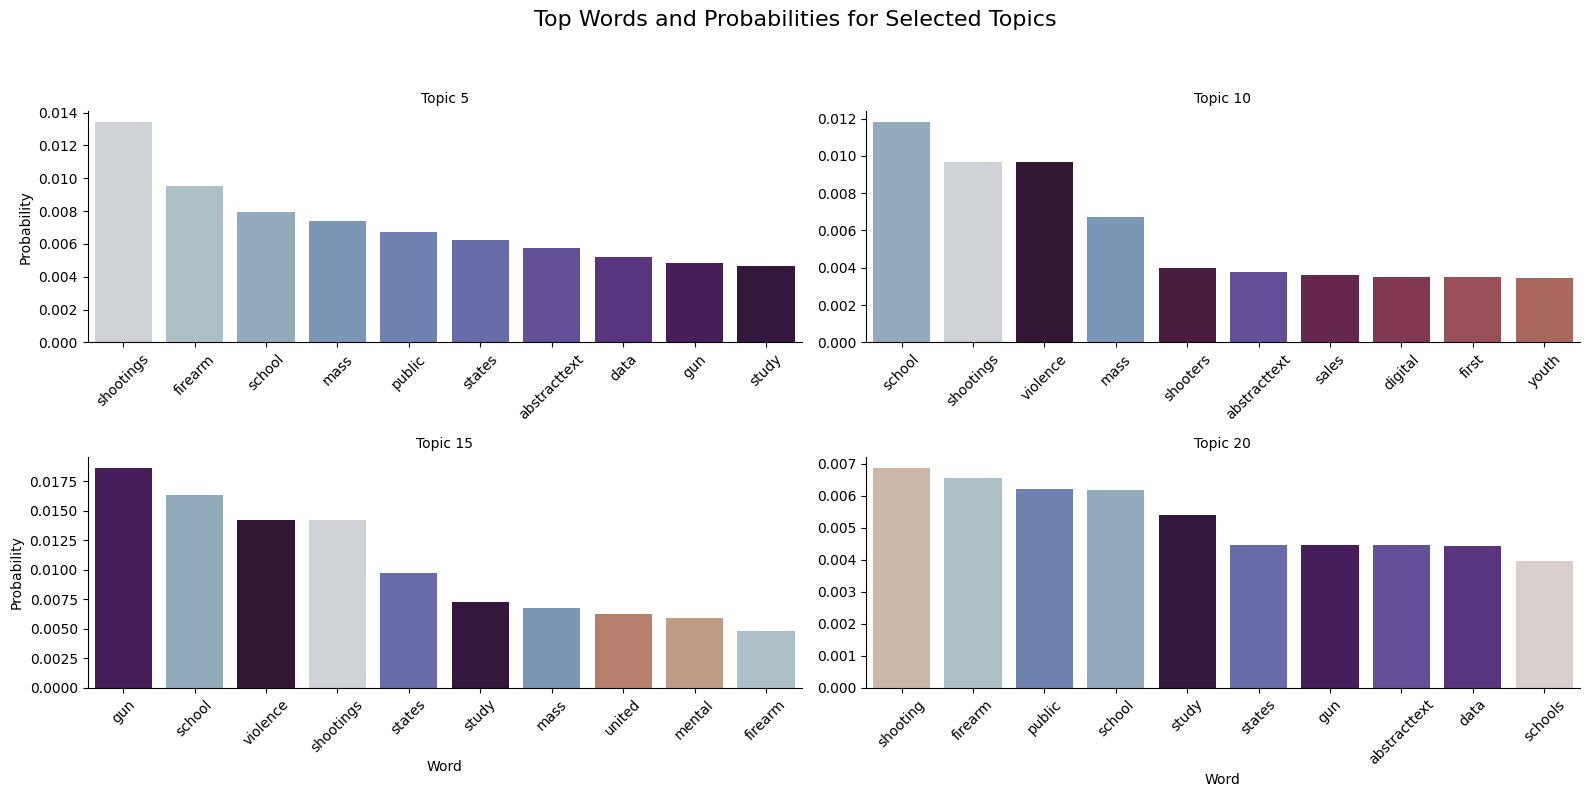

In [243]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## **Task 4.1 Based on your results answer the following:**

**Give a label to each topic number (such as Topic 1: Health Care)**  
Topic 5: Study on Mass Shootings in Schools   
Topic 10: Violent Mass Shootings for First Time Youth   
Topic 15: Study on Effects of Gun Violence in Schools on Mental Health    
Topic 20: Data on Shootings in Public Schools   

**Which topics appear most distinct?**  
Topic 5 and 15 are more distinctly about firearms and mass shootings.

**Which topics overlap substantially?**   
There is substantial overlap in Topics 5, 15, and 20. They all have gun, school, shooting, firearm, and study.

**Do the top keywords align with your expectations from the dataset?**  
The top keywords do align with my expectations. My search was for articles about school shootings in the United States and that is what I got. The only thing I did not expect was "abstracttext." Even though I added it as a stopword it still persisted in my visual.

## **✅ TASK 5 [2 Points]: At the end of your Colab notebook, create a new text cell, and write a brief reflection for this assignment in a few sentences addressing the following:**

**What went well? What did not go well or what challenges you encountered?**  
What went went well in this lab was the removal of warnings and the download of the csv file. With the warnings removed from the output I was better able to understand it. Then with the csv file, it was easy to search and filter to get my desired metadata. What did not go well was the cleaning of my corpus and the running of my code. I kept having to go back and add more stop words because when I would rerun it, it would produce more random topic words. Also, in general when running my code, it took a long time. I found myself having to close the page multiple times because outputs would get stuck loading.


**In what ways could topic modeling be integrated into your current or future professional or research work?**  
I think topic modeling could be integreatted in my future research in graduate school. I plan on getting my masters and doctorate in clinical psychology, so I can see this skill being useful. Other than that though, I do not see any reason why I would need topic modeling.